# Tensorflow

## Importowanie bibliotek

In [13]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/ml-next-step/src")

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Inicjalizacja konfiguracji

In [3]:
class config:
    
    # Ścieżki do plików
    NEW_DATA_PATH = "data/train_new.csv"

    # Ogólne ustawienia projektu
    RANDOMIZE_DATA = True
    FOLDS_CNT = 5

## Załadowanie danych

In [4]:
# Załadowanie danych MNIST
df = pd.read_csv(config.NEW_DATA_PATH)

df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,label,kfold
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,7,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,3
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,4
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,4,2
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,2


## Sieć neuronowa

In [5]:
def use_model(df_train, df_test, model):

    # Podział danych na odpowiednie zmienne
    x_train = df_train.loc[:, df_train.columns != "label"].values
    y_train = df_train.loc[:, "label"].values

    x_test = df_test.loc[:, df_test.columns != "label"].values
    y_test = df_test.loc[:, "label"].values
    
    # Trenowanie modelu oraz zwrócenie wyników
    result = model.fit(
        x_train,
        y_train,
        batch_size=64,
        epochs=10,
        validation_data=(x_test, y_test),
        
    )
    return result

In [6]:
# Inicjalizacja tablicy z rezultatami modeli
results_arr = []

# Testowanie sieci neuronowej na różnych foldach
for fold in range(config.FOLDS_CNT):
    
    # Inicjalizacja train oraz test dataframe
    df_train = df.loc[df["kfold"] != fold, df.columns != "kfold"]
    df_test = df.loc[df["kfold"] == fold, df.columns != "kfold"]

    # Stworzenie modelu
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(shape=(28*28, )), # Warstwa wejściowa
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax") # Warstwa wyjściowa
    ])
    
    # Kompilacja modelu
    model.compile(
        optimizer="Adam",
        loss="SparseCategoricalCrossentropy",
        metrics=["SparseCategoricalAccuracy"]
    )

    # Wygenerowanie wyników
    result = use_model(df_train, df_test, model)

    # Dodanie wyników do tablicy rezultatów
    results_arr.append(result)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - SparseCategoricalAccuracy: 0.7200 - loss: 15.7172 - val_SparseCategoricalAccuracy: 0.8915 - val_loss: 2.1191
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - SparseCategoricalAccuracy: 0.9248 - loss: 1.1347 - val_SparseCategoricalAccuracy: 0.9015 - val_loss: 1.7460
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - SparseCategoricalAccuracy: 0.9536 - loss: 0.4745 - val_SparseCategoricalAccuracy: 0.9100 - val_loss: 1.3986
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - SparseCategoricalAccuracy: 0.9641 - loss: 0.3358 - val_SparseCategoricalAccuracy: 0.9200 - val_loss: 1.5493
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - SparseCategoricalAccuracy: 0.9782 - loss: 0.1805 - val_SparseCategoricalAccuracy: 0.9295 - val_loss: 1.3305
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - SparseCategoricalAccuracy: 0.9777 - loss: 0.2354 - val_SparseCategoricalAccuracy: 0.9205 - val_loss: 1.3593
Epoch 7/10
125/125 ━━━━━━━━

## Wyświetlenie wyników

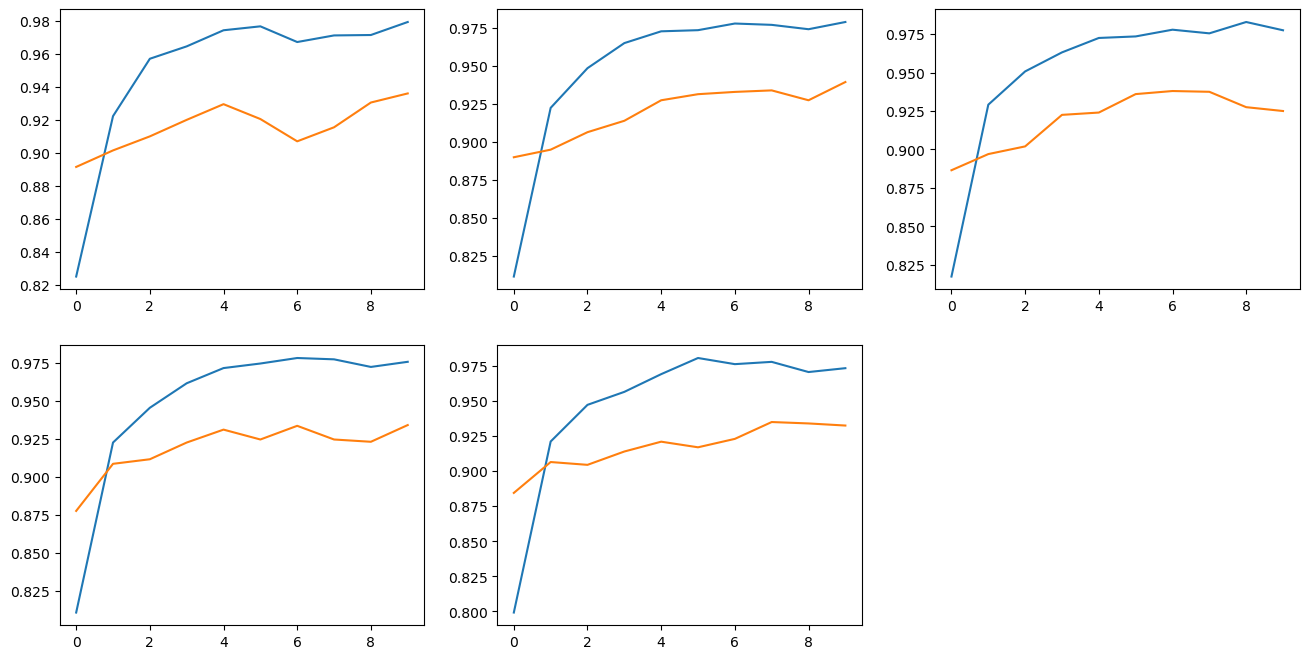

In [8]:
# Ustawienie rozmiaru ekranu, na którym wyświetlą się wykresy
fig = plt.figure(figsize=(16, 8))

# Przejście po tablicy rezultatów
for index, result in enumerate(results_arr):
    
    # Wygenerowanie wykresu dla wyników accuracy
    fig.add_subplot((config.FOLDS_CNT - 1) // 3 + 1, 3, index + 1)

    # plt.xlim(0, 20)
    # plt.ylim(0, 1)
    
    plt.plot(result.history["SparseCategoricalAccuracy"])
    plt.plot(result.history["val_SparseCategoricalAccuracy"])

# Wyświetlenie wykresów
plt.show()

In [20]:
# Średnia wartość accuracy
acc = np.mean(result.history["SparseCategoricalAccuracy"])
val_acc = np.mean(result.history["val_SparseCategoricalAccuracy"])

print(f"avg accuracy: {acc}")
print(f"avg val_accuracy: {val_acc}")

avg accuracy: 0.9471999943256378
avg val_accuracy: 0.9171999990940094


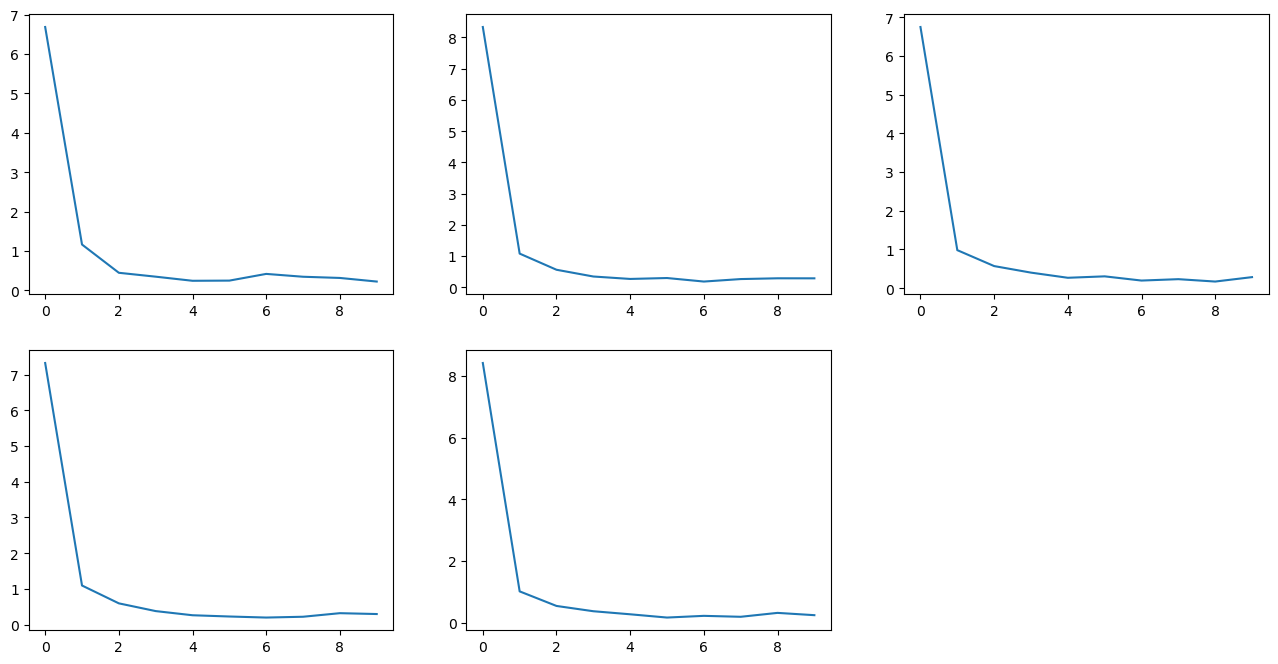

In [9]:
# Ustawienie rozmiaru ekranu, na którym wyświetlą się wykresy
fig = plt.figure(figsize=(16, 8))

# Przejście po tablicy rezultatów
for index, result in enumerate(results_arr):
    
    # Wygenerowanie wykresu dla strat
    fig.add_subplot((config.FOLDS_CNT - 1) // 3 + 1, 3, index + 1)
    plt.plot(result.history["loss"])

# Wyświetlenie wykresów
plt.show()